# PCA Project — Breast Cancer Dataset

## Project goal

This project applies **Principal Component Analysis (PCA)** to reduce the dimensionality of the Breast Cancer Wisconsin dataset while retaining as much variance/information as possible.

### Learning goals
- Understand the dataset before applying PCA.
- Split the data before learning preprocessing parameters.
- Standardize features before PCA.
- Understand explained variance and cumulative explained variance.
- Decide how many principal components to retain.
- Visualize the data using principal components.
- Understand the difference between **dimensionality reduction** and **prediction**.

## 1. Load the dataset

We use `load_breast_cancer()` from scikit-learn. The dataset contains 569 observations and 30 numerical features. The target has two classes: malignant and benign.

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name='target'
)

In [2]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X.shape

(569, 30)

In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### Dataset observations

- `X` contains the **input features**.
- `y` contains the **target**.
- `X` has **30 features**, which makes this a useful dataset for demonstrating dimensionality reduction.
- PCA will be applied to **X**, not to `y`.

A key idea from PCA:

> PCA creates new features called **principal components**. It does not simply select the best original columns.


In [5]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [6]:
X.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

In [7]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

### EDA observations

- The features are numerical.
- There are no missing values in the input features, so no imputation is required for this project.
- The features have very different numerical scales.

That last point is important because PCA is variance-based. A feature with a much larger numerical scale can have a much larger variance simply because of its units.

Therefore, **scaling is required before PCA** for this project.


## 2. Train/Test Split

We split the data before fitting the scaler. This prevents information from the test set from influencing preprocessing.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
X_train.shape

(455, 30)

In [10]:
X_test.shape

(114, 30)

### Why `stratify=y`?

This is a classification dataset with two target classes. `stratify=y` helps keep approximately the same class proportions in the training and test sets.


## 3. Standardize the features

StandardScaler transforms each feature so that, based on the training data, it is centered around 0 and has standard deviation 1.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_trans = scaler.fit_transform(X_train)
X_test_trans = scaler.transform(X_test)

### Why scaling matters for PCA

PCA searches for directions with maximum variance.

Suppose one feature has values around `0–10` and another has values around `0–100000`. Without scaling, the second feature can contribute much more to the variance calculation because of its numerical scale.

Scaling puts the features on a comparable scale before PCA.

> **Scaling does not remove outliers.** It changes the numerical scale of the features.


## 4. Initial PCA with 2 components

We first use two components so that the transformed data can later be visualized in a 2D plot.

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_trans)
X_test_pca = pca.transform(X_test_trans)

In [13]:
pca.explained_variance_ratio_

array([0.44413492, 0.18944618])

### What does `explained_variance_ratio_` mean?

Each value tells us the proportion of the total variance captured by that principal component.

For this dataset and split:

- PC1 captures about **44.41%**
- PC2 captures about **18.94%**
- Together, the first two components capture about **63.36%**

So reducing 30 features directly to 2 components gives a convenient visualization, but it does **not** retain all of the original variation.


## 5. Fit PCA with all components to study explained variance

Before deciding how many components to keep, we inspect all 30 possible components.

In [14]:
pca_full = PCA()
pca_full.fit(X_train_trans)

pca_full.explained_variance_ratio_

array([4.44134918e-01, 1.89446183e-01, 9.54335633e-02, 6.72468941e-02,
       5.51769040e-02, 3.93453424e-02, 2.18176591e-02, 1.58331722e-02,
       1.27878330e-02, 1.14544250e-02, 9.26269214e-03, 8.47428916e-03,
       7.99746679e-03, 5.30706257e-03, 3.12250212e-03, 2.57146110e-03,
       2.03925720e-03, 1.86696858e-03, 1.49100638e-03, 1.03671459e-03,
       9.25703045e-04, 8.66421035e-04, 7.19778970e-04, 5.88332657e-04,
       5.04652748e-04, 2.45507775e-04, 2.16103111e-04, 5.71732867e-05,
       2.57352579e-05, 4.27774949e-06])

In [15]:
import numpy as np

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

cumulative_variance * 100

array([ 44.41349176,  63.35811007,  72.90146639,  79.62615581,
        85.1438462 ,  89.07838044,  91.26014635,  92.84346357,
        94.12224687,  95.26768937,  96.19395859,  97.0413875 ,
        97.84113418,  98.37184044,  98.68409065,  98.94123676,
        99.14516248,  99.33185934,  99.48095998,  99.58463144,
        99.67720174,  99.76384384,  99.83582174,  99.89465501,
        99.94512028,  99.96967106,  99.99128137,  99.9969987 ,
        99.99957223, 100.        ])

### Cumulative explained variance

Cumulative explained variance tells us how much total variance is retained when we keep the first `n` components.

For example:

```text
PC1 + PC2 + PC3 + ... + PCn
        ↓
total variance retained
```

This is useful because PCA is a trade-off:

- fewer components → stronger dimensionality reduction
- more components → more variance retained

A threshold such as **95%** is a common starting point, but it is not a universal rule.


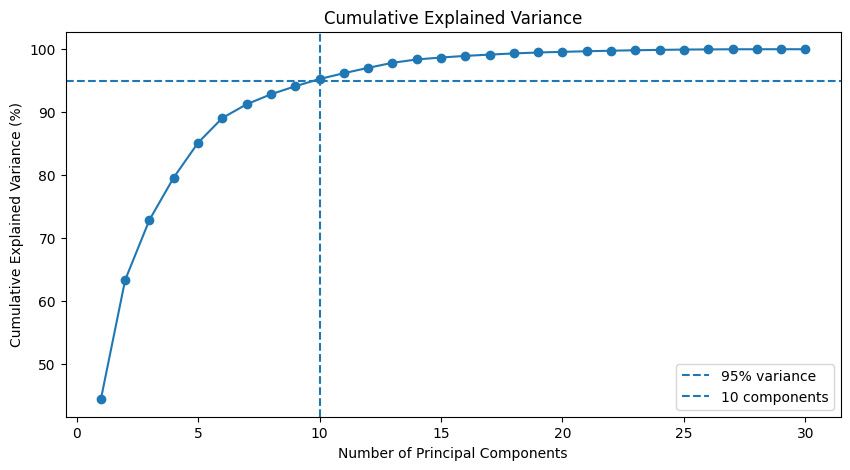

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")

plt.axhline(95, linestyle='--', label='95% variance')
plt.axvline(10, linestyle='--', label='10 components')

plt.legend()
plt.show()

### Component selection

For this train/test split:

- **10 components retain about 95.27%** of the variance.
- **12 components retain about 97.04%** of the variance.
- Therefore, if the project goal is specifically to retain at least 95%, **10 components are sufficient**.
- Keeping 12 is also valid if we intentionally want to retain more information, but it is not necessary just to cross the 95% threshold.

The important point is to connect the number of components to the variance-retention goal rather than choosing a number arbitrarily.


## 6. PCA with the selected number of components

Here we use **10 components** because they are enough to retain at least 95% of the training-data variance.

In [17]:
pca_reduced = PCA(n_components=10)

X_train_pca = pca_reduced.fit_transform(X_train_trans)
X_test_pca = pca_reduced.transform(X_test_trans)

In [18]:
pca_reduced.explained_variance_ratio_.sum() * 100

95.26768937417548

In [19]:
X_train_pca.shape

(455, 10)

In [20]:
X_test_pca.shape

(114, 10)

### Interpretation

Originally:

```text
455 training rows × 30 features
114 test rows × 30 features
```

After PCA:

```text
455 training rows × 10 components
114 test rows × 10 components
```

So we reduced the feature space from **30 dimensions to 10 dimensions** while retaining approximately **95.27% of the training-data variance**.

The 10 columns are now:

```text
PC1, PC2, ..., PC10
```

They are new features created by PCA, not the original 30 feature columns.


## 7. Visualize the first two principal components

Even though we retained 10 components for dimensionality reduction, we can plot PC1 and PC2 because a 2D graph is easy to visualize.

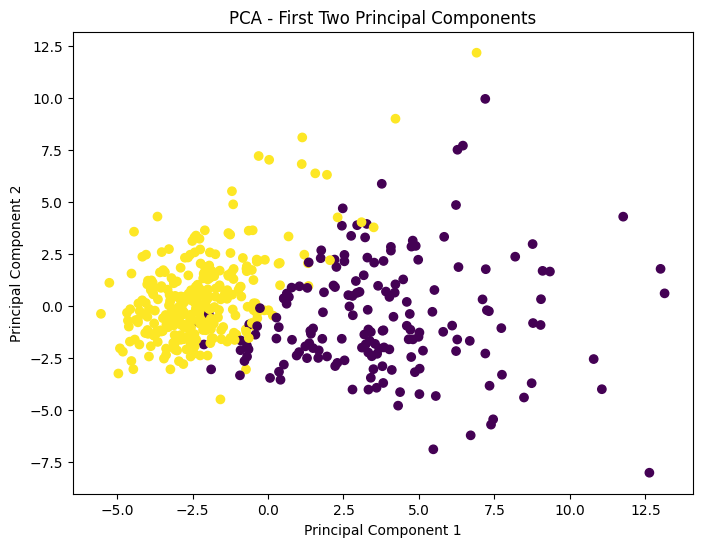

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - First Two Principal Components")

plt.show()

### What this plot shows

Each point represents one training observation after transformation into PCA space.

- x-axis → PC1
- y-axis → PC2
- `c=y_train` colors the points according to the target class.

This is useful for visually checking whether the two classes appear separated in the first two principal-component directions.

## 8. Logistic Regression after PCA

Now that we have learned **Logistic Regression, confusion matrix, and classification metrics**, we can use them to continue this PCA project.

Here the goal is not to replace PCA with Logistic Regression. PCA is still the **dimensionality-reduction step**. Logistic Regression is the **classification model** that uses the reduced features.

### Workflow

```text
Original 30 features
        ↓
StandardScaler
        ↓
PCA → 10 components
        ↓
Logistic Regression
        ↓
Predicted probability
        ↓
Threshold (default 0.5)
        ↓
Predicted class
```

**Important:** PCA does not use `y`. It only learns directions of maximum variance from `X_train`. Logistic Regression uses `y_train` to learn how the PCA components relate to the target classes.

In [ ]:
from sklearn.linear_model import LogisticRegression

lor_pca = LogisticRegression(max_iter=1000)
lor_pca.fit(X_train_pca, y_train)

### Predict classes and probabilities

`predict()` gives the final class (`0` or `1`).

`predict_proba()` gives probabilities for each class. The second column (`[:, 1]`) is the probability of class `1`.

The default classification threshold is **0.5**.

In [ ]:
y_pred_pca = lor_pca.predict(X_test_pca)
y_pred_proba_pca = lor_pca.predict_proba(X_test_pca)[:, 1]

print("First 10 predicted classes:")
print(y_pred_pca[:10])

print("\nFirst 10 probabilities for class 1:")
print(y_pred_proba_pca[:10])

## 9. Confusion Matrix

The confusion matrix shows **what kind of predictions were correct or incorrect**.

```text
                 Predicted
                0        1
Actual  0      TN       FP
        1      FN       TP
```

- **TN:** actual 0, predicted 0
- **FP:** actual 0, predicted 1
- **FN:** actual 1, predicted 0
- **TP:** actual 1, predicted 1

### Dataset-specific note

In scikit-learn's Breast Cancer dataset, `0 = malignant` and `1 = benign`. Therefore, with the default metric settings, **class 1 (benign) is treated as the positive class**. Keep this in mind when interpreting precision, recall, and F1.

In [ ]:
from sklearn.metrics import confusion_matrix

cm_pca = confusion_matrix(y_test, y_pred_pca)
TN, FP, FN, TP = cm_pca.ravel()

print(cm_pca)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(cm_pca)
plt.title("Confusion Matrix — Logistic Regression after PCA")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.xticks([0, 1], ["0 (Malignant)", "1 (Benign)"])
plt.yticks([0, 1], ["0 (Malignant)", "1 (Benign)"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_pca[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 10. Classification Metrics

We now measure how well the classifier performs.

- **Accuracy:** overall fraction of correct predictions.
- **Precision:** among samples predicted as the positive class, how many were actually positive?
- **Recall:** among actual positive samples, how many did the model correctly identify?
- **F1-score:** harmonic mean of precision and recall.

For this dataset, the positive class is `1 = benign` under the default scikit-learn metric settings.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_pca = accuracy_score(y_test, y_pred_pca)
precision_pca = precision_score(y_test, y_pred_pca)
recall_pca = recall_score(y_test, y_pred_pca)
f1_pca = f1_score(y_test, y_pred_pca)
roc_auc_pca = roc_auc_score(y_test, y_pred_proba_pca)

print("Accuracy :", accuracy_pca)
print("Precision:", precision_pca)
print("Recall   :", recall_pca)
print("F1-score :", f1_pca)
print("ROC-AUC  :", roc_auc_pca)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_pca))

## 11. ROC-AUC

`ROC-AUC` evaluates how well the model ranks the two classes across different probability thresholds.

Unlike accuracy, ROC-AUC uses the **probabilities/scores**, not only the final `0/1` predictions.

- AUC close to **1** → strong class separation.
- AUC around **0.5** → roughly random ranking.


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_pca, tpr_pca, thresholds_pca = roc_curve(y_test, y_pred_proba_pca)
auc_pca = roc_auc_score(y_test, y_pred_proba_pca)

plt.figure(figsize=(7, 5))
plt.plot(fpr_pca, tpr_pca, label=f"PCA + Logistic Regression (AUC = {auc_pca:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 12. Compare Logistic Regression before and after PCA

To understand the effect of PCA, we compare two classifiers using the **same train/test split and the same standardized input**:

1. Logistic Regression using all **30 standardized original features**.
2. Logistic Regression using the **10 PCA components**.

This is a useful experiment because PCA reduces the number of features, but dimensionality reduction can also remove some information useful for classification.

In [ ]:
lor_original = LogisticRegression(max_iter=1000)
lor_original.fit(X_train_trans, y_train)

y_pred_original = lor_original.predict(X_test_trans)
y_pred_proba_original = lor_original.predict_proba(X_test_trans)[:, 1]

comparison = pd.DataFrame({
    "Model": ["Logistic Regression (30 features)", "PCA + Logistic Regression (10 components)"],
    "Features": [30, 10],
    "Accuracy": [
        accuracy_score(y_test, y_pred_original),
        accuracy_score(y_test, y_pred_pca)
    ],
    "Precision": [
        precision_score(y_test, y_pred_original),
        precision_score(y_test, y_pred_pca)
    ],
    "Recall": [
        recall_score(y_test, y_pred_original),
        recall_score(y_test, y_pred_pca)
    ],
    "F1": [
        f1_score(y_test, y_pred_original),
        f1_score(y_test, y_pred_pca)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_proba_original),
        roc_auc_score(y_test, y_pred_proba_pca)
    ]
})

comparison